# 8

In [597]:
import pandas as pd

Create a sample dataset

In [598]:
df = pd.DataFrame([{'product_id':23, 'name':'computer', 'wholesale_price': 500, 'retail_price':1000, 'sales':100},
                   {'product_id':96, 'name':'Python Workout', 'wholesale_price': 35, 'retail_price':75, 'sales':1000},
                   {'product_id':97, 'name':'Pandas Workout', 'wholesale_price': 35, 'retail_price':75, 'sales':500},
                   {'product_id':15, 'name':'banana', 'wholesale_price': 0.5, 'retail_price':1, 'sales':200},
                   {'product_id':87, 'name':'sandwich', 'wholesale_price': 3,'retail_price':5, 'sales':300},
                   ])

In [599]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       5 non-null      int64  
 1   name             5 non-null      object 
 2   wholesale_price  5 non-null      float64
 3   retail_price     5 non-null      int64  
 4   sales            5 non-null      int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 332.0+ bytes


In [600]:
df

,product_id,name,wholesale_price,retail_price,sales
0,23,computer,500.0,1000,100
1,96,Python Workout,35.0,75,1000
2,97,Pandas Workout,35.0,75,500
3,15,banana,0.5,1,200
4,87,sandwich,3.0,5,300


Calculate the total profit

In [601]:
((df['retail_price'] - df['wholesale_price']) * df['sales']).sum()

np.float64(110700.0)

For what products is the retail price more than twice the wholesale price?

In [602]:
df.loc[df['retail_price'] / df['wholesale_price'] > 2, 'name']

1    Python Workout
2    Pandas Workout
Name: name, dtype: object

How much did the store make from food versus computers versus books?

In [603]:
food = df.loc[[3,4]]
books = df.loc[[1,2]]

((food['retail_price'] - food['wholesale_price']) * food['sales']).sum(), ((books['retail_price'] - books['wholesale_price']) * books['sales']).sum()

(np.float64(700.0), np.float64(60000.0))

Because your store is doing so well, you can negotiate a 30% discount on the
wholesale price of goods. Calculate the new net income.

In [604]:
df['wholesale_price'] = df['wholesale_price'] * 0.7
((df['retail_price'] - df['wholesale_price']) * df['sales']).sum()

np.float64(141750.0)

# 9

Your local government is thinking about imposing a sales tax and is considering 15%, 20%, and 25% rates.
Show how much less you would net with each of these tax amounts by adding columns to the data frame for your net income under each of the proposed rates, as well as your current net income.


In [605]:
df['current_net'] = ((df['retail_price'] - df['wholesale_price']) * df['sales'])
# round all values in the dataframe to 2 decimal places
df = df.round(2)
df

,product_id,name,wholesale_price,retail_price,sales,current_net
0,23,computer,350.00,1000,100,65000.0
1,96,Python Workout,24.50,75,1000,50500.0
2,97,Pandas Workout,24.50,75,500,25250.0
3,15,banana,0.35,1,200,130.0
4,87,sandwich,2.10,5,300,870.0


In [606]:
df['tax_15'] = df['current_net'] * 0.85
df['tax_20'] = df['current_net'] * 0.8
df['tax_25'] = df['current_net'] * 0.75
df = df.round(2)

In [607]:
df

,product_id,name,wholesale_price,retail_price,sales,current_net,tax_15,tax_20,tax_25
0,23,computer,350.00,1000,100,65000.0,55250.0,52000.0,48750.0
1,96,Python Workout,24.50,75,1000,50500.0,42925.0,40400.0,37875.0
2,97,Pandas Workout,24.50,75,500,25250.0,21462.5,20200.0,18937.5
3,15,banana,0.35,1,200,130.0,110.5,104.0,97.5
4,87,sandwich,2.10,5,300,870.0,739.5,696.0,652.5


In [608]:
df[['current_net', 'tax_15', 'tax_20', 'tax_25']].sum()

current_net    141750.0
tax_15         120487.5
tax_20         113400.0
tax_25         106312.5
dtype: float64

In [609]:
df

,product_id,name,wholesale_price,retail_price,sales,current_net,tax_15,tax_20,tax_25
0,23,computer,350.00,1000,100,65000.0,55250.0,52000.0,48750.0
1,96,Python Workout,24.50,75,1000,50500.0,42925.0,40400.0,37875.0
2,97,Pandas Workout,24.50,75,500,25250.0,21462.5,20200.0,18937.5
3,15,banana,0.35,1,200,130.0,110.5,104.0,97.5
4,87,sandwich,2.10,5,300,870.0,739.5,696.0,652.5


An alternative tax plan would charge a 25% tax, but only on products from which you would net more than 20,000.

In [610]:
# if the current_net is > 20000, the applied tax is 25%
# otherwise, no tax is applied
# calculate the total net income
if df['current_net'].sum() > 20000:
    df['total_net'] = df['current_net'] * 0.75
else:
    df['total_net'] = df['current_net']
    # round all values in the dataframe to 2 decimal places
df = df.round(2)
df[['current_net', 'total_net']].sum()

current_net    141750.0
total_net      106312.5
dtype: float64

Yet another alternative tax plan would charge:
 - a 25% tax on products whose retail price is greater than 80
 - a 10% tax on products whose retail price is between 30 and 80,
 - and no tax on other products

In [611]:
# Using lambda with apply
df['total_net'] = df.apply(lambda row: row['current_net'] * 0.75 if row['retail_price'] > 80
                          else row['current_net'] * 0.9 if 30 < row['retail_price'] <= 80
                          else row['current_net'], axis=1)

# round all values in the dataframe to 2 decimal places
df = df.round(2)
df

,product_id,name,wholesale_price,retail_price,sales,current_net,tax_15,tax_20,tax_25,total_net
0,23,computer,350.00,1000,100,65000.0,55250.0,52000.0,48750.0,48750.0
1,96,Python Workout,24.50,75,1000,50500.0,42925.0,40400.0,37875.0,45450.0
2,97,Pandas Workout,24.50,75,500,25250.0,21462.5,20200.0,18937.5,22725.0
3,15,banana,0.35,1,200,130.0,110.5,104.0,97.5,130.0
4,87,sandwich,2.10,5,300,870.0,739.5,696.0,652.5,870.0


In [612]:
# Create total_net column with default values (no tax)
df['total_net'] = df['current_net']

# Apply 25% tax where retail_price > 80
df.loc[df['retail_price'] > 80, 'total_net'] = df.loc[df['retail_price'] > 80, 'current_net'] * 0.75

# Apply 10% tax where 30 < retail_price <= 80
df.loc[(df['retail_price'] > 30) & (df['retail_price'] <= 80), 'total_net'] = df.loc[(df['retail_price'] > 30) & (df['retail_price'] <= 80), 'current_net'] * 0.9

# Round all values in the dataframe to 2 decimal places
df = df.round(2)
df

,product_id,name,wholesale_price,retail_price,sales,current_net,tax_15,tax_20,tax_25,total_net
0,23,computer,350.00,1000,100,65000.0,55250.0,52000.0,48750.0,48750.0
1,96,Python Workout,24.50,75,1000,50500.0,42925.0,40400.0,37875.0,45450.0
2,97,Pandas Workout,24.50,75,500,25250.0,21462.5,20200.0,18937.5,22725.0
3,15,banana,0.35,1,200,130.0,110.5,104.0,97.5,130.0
4,87,sandwich,2.10,5,300,870.0,739.5,696.0,652.5,870.0


# 10

In [613]:
df = pd.DataFrame([{'product_id':23, 'name':'computer', 'wholesale_price': 500, 'retail_price':1000, 'sales':100},
                   {'product_id':96, 'name':'Python Workout', 'wholesale_price': 35, 'retail_price':75, 'sales':1000},
                   {'product_id':97, 'name':'Pandas Workout', 'wholesale_price': 35, 'retail_price':75, 'sales':500},
                   {'product_id':15, 'name':'banana', 'wholesale_price': 0.5, 'retail_price':1, 'sales':200},
                   {'product_id':87, 'name':'sandwich', 'wholesale_price': 3,'retail_price':5, 'sales':300},
                   ])

Create a new dataframe:

In [614]:
new_products = pd.DataFrame([{'product_id':24, 'name':'phone',
'wholesale_price': 200, 'retail_price':500},
{'product_id':16, 'name':'apple', 'wholesale_price': 0.5,
'retail_price':1},
{'product_id':17, 'name':'pear', 'wholesale_price': 0.6,
'retail_price':1.2}], index=range(5,8))

In [615]:
df = pd.concat([df, new_products])
df

,product_id,name,wholesale_price,retail_price,sales
0,23,computer,500.0,1000.0,100.0
1,96,Python Workout,35.0,75.0,1000.0
2,97,Pandas Workout,35.0,75.0,500.0
3,15,banana,0.5,1.0,200.0
4,87,sandwich,3.0,5.0,300.0
5,24,phone,200.0,500.0,NaN
6,16,apple,0.5,1.0,NaN
7,17,pear,0.6,1.2,NaN


In [616]:
df.loc[[5,6,7], 'sales'] = [100, 200, 75]

Add a new column, department, to the data frame. Place each product in a department:

In [617]:
df['department'] = ['electronics', 'books', 'books', 'food', 'food', 'electronics', 'food', 'food']
df

,product_id,name,wholesale_price,retail_price,sales,department
0,23,computer,500.0,1000.0,100.0,electronics
1,96,Python Workout,35.0,75.0,1000.0,books
2,97,Pandas Workout,35.0,75.0,500.0,books
3,15,banana,0.5,1.0,200.0,food
4,87,sandwich,3.0,5.0,300.0,food
5,24,phone,200.0,500.0,100.0,electronics
6,16,apple,0.5,1.0,200.0,food
7,17,pear,0.6,1.2,75.0,food


In [618]:
df['current_net'] = ((df['retail_price'] - df['wholesale_price']) * df['sales'])
# round all values in the dataframe to 2 decimal places
df = df.round(2)
df

,product_id,name,wholesale_price,retail_price,sales,department,current_net
0,23,computer,500.0,1000.0,100.0,electronics,50000.0
1,96,Python Workout,35.0,75.0,1000.0,books,40000.0
2,97,Pandas Workout,35.0,75.0,500.0,books,20000.0
3,15,banana,0.5,1.0,200.0,food,100.0
4,87,sandwich,3.0,5.0,300.0,food,600.0
5,24,phone,200.0,500.0,100.0,electronics,30000.0
6,16,apple,0.5,1.0,200.0,food,100.0
7,17,pear,0.6,1.2,75.0,food,45.0


In [619]:
df['current_net'].sum()

np.float64(140845.0)

Use the query method to get the descriptive statistics for food items.

In [620]:
df.query('department == "food"')['current_net'].describe()

count      4.00000
mean     211.25000
std      260.46033
min       45.00000
25%       86.25000
50%      100.00000
75%      225.00000
max      600.00000
Name: current_net, dtype: float64

# 11

Find the IDs and names of products that have sold more than the average number of units using:
   - the loc method
   - the query method

In [621]:
df.loc[
    df['sales'] > df['sales'].mean(),
    ['product_id', 'name']
]

,product_id,name
1,96,Python Workout
2,97,Pandas Workout


In [622]:
df.query('sales > sales.mean()')[['product_id', 'name']]

,product_id,name
1,96,Python Workout
2,97,Pandas Workout


Show the ID and name of products whose net income is in the top 25%
quantile.

In [623]:
df.query('current_net > current_net.quantile(q=0.75)')[['product_id', 'name']]

,product_id,name
0,23,computer
1,96,Python Workout


Show the ID and name of products with lower-than-average sales numbers and whose wholesale price is greater than the average.

In [624]:
df.query('sales < sales.mean() and wholesale_price > wholesale_price.mean()')[['product_id', 'name']]

,product_id,name
0,23,computer
5,24,phone


Show the name and wholesale and retail prices of products with IDs between 80
and 100 and that sold fewer than 400 units.

In [625]:
df.query('product_id > 80 and product_id < 100 and sales < 400')[['name', 'wholesale_price', 'retail_price']]

,name,wholesale_price,retail_price
4,sandwich,3.0,5.0


# 12

Load the taxi dataset from the data folder. The dataset contains two columns: passenger count and trip distance. Use the IQR method to find out how many trip distances were outliers.

In [626]:
passengers = pd.read_csv('data/taxi-passenger-count.csv', header=None).squeeze()
distance = pd.read_csv('data/taxi-distance.csv', header=None).squeeze()
df = pd.DataFrame({'trip_distance': distance, 'passenger_count': passengers})

In [627]:
df.describe()

,trip_distance,passenger_count
count,9999.000000,9999.000000
mean,3.158511,1.659466
std,4.037516,1.333306
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.700000,1.000000
75%,3.300000,2.000000
max,64.600000,6.000000



Count how many trip distances were outliers.

In [628]:
iqr = (df['trip_distance'].quantile(0.75) - df['trip_distance'].quantile(0.25))
iqr

np.float64(2.3)

Let’s start with outliers on the low end: distances less than the 25% quantile by at least 1.5 * the IQR.

The 1.5 multiplier in the interquartile range (IQR) calculation is a standard statistical convention known as "Tukey's fences" for identifying outliers. This method was developed by statistician John Tukey.

There are no outliers on the low end:

In [629]:
df[df['trip_distance'] < df['trip_distance'].quantile(0.25) - 1.5*iqr]

,trip_distance,passenger_count


On the high end, though:

In [630]:
df[df['trip_distance'] > df['trip_distance'].quantile(0.75) + 1.5*iqr]

,trip_distance,passenger_count
7,11.90,4
60,9.30,1
73,12.65,1
82,10.24,3
88,23.76,2
...,...,...
9975,7.60,1
9976,12.60,1
9979,11.30,1
9980,9.13,1


And then the passenger count for those outliers:

In [631]:
df['passenger_count'][df['trip_distance'] > df['trip_distance'].quantile(0.75) + 1.5*iqr]

7       4
60      1
73      1
82      3
88      2
       ..
9975    1
9976    1
9979    1
9980    1
9982    1
Name: passenger_count, Length: 1219, dtype: int64

In [632]:
df['passenger_count'][df['trip_distance'] > df['trip_distance'].quantile(0.75) + 1.5*iqr].mean()

np.float64(1.7301066447908122)

If you define outliers to be the lowest 10% and highest 10% of values, how many were there?

In [633]:
df[df['trip_distance'] < df['trip_distance'].quantile(0.10) - 1.5*iqr]

,trip_distance,passenger_count


In [634]:
df[df['trip_distance'] < df['trip_distance'].quantile(0.10) + 1.5*iqr]

,trip_distance,passenger_count
0,1.63,1
1,0.46,1
2,0.87,1
3,2.13,1
4,1.40,1
...,...,...
9988,0.90,1
9989,1.34,6
9991,1.48,1
9994,2.70,1


How many short, medium, and long trips had only one passenger?

In [635]:
df['cat_distance'] = pd.cut(df['trip_distance'],
         bins=[0, 2, 10, df['trip_distance'].max()],
         include_lowest=True,
         labels=['short', 'medium', 'long'])

In [636]:
df[df['passenger_count'] == 1].groupby('cat_distance', observed=False)['trip_distance'].count()

cat_distance
short     4333
medium    2387
long       487
Name: trip_distance, dtype: int64

It is also possible to use the `scipy` library to find outliers. The `trimboth` function from the `scipy.stats` module can be used to trim the top and bottom values from a dataset. Using the 10% trimming:

In [637]:
from scipy import stats

In [638]:
stats.trimboth(df['trip_distance'], proportiontocut=0.1)

array([0.63, 0.63, 0.63, ..., 8.2 , 8.2 , 8.2 ], shape=(8001,))

The `scipy.stats.zscore` function rescales the data so the standard deviation 1.

It does not change how the data is distributed.


In [639]:
trip_normalized = pd.Series(stats.zscore(df['trip_distance'], ddof=1))
trip_normalized

0      -0.378577
1      -0.668359
2      -0.566812
3      -0.254739
4      -0.435543
          ...   
9994   -0.113563
9995    0.332256
9996    0.602224
9997   -0.400868
9998    0.654236
Length: 9999, dtype: float64

In [640]:
trip_normalized.describe()

count    9.999000e+03
mean     4.547928e-17
std      1.000000e+00
min     -7.822906e-01
25%     -5.346136e-01
50%     -3.612396e-01
75%      3.504361e-02
max      1.521765e+01
dtype: float64

In [641]:
# Find distances where absolute z-score > 3
above_3_z = df[abs(trip_normalized) > 3]['trip_distance']
above_3_z.count()

np.int64(306)

<Axes: ylabel='Frequency'>

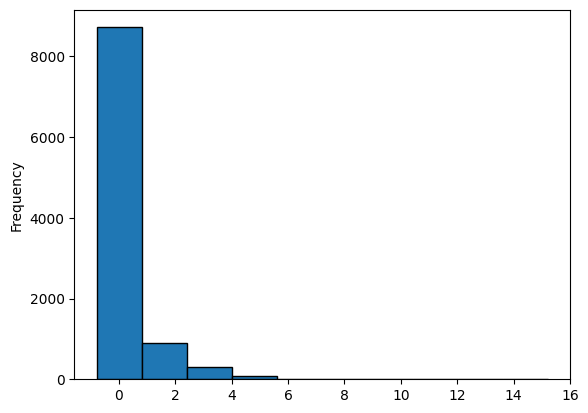

In [642]:
trip_normalized.plot.hist(edgecolor='black')

Let's check it using a Q-Q (Quantile-Quantile) plot

1. **The straight diagonal line** represents where points would fall if the data perfectly followed a normal distribution
2. **Points following the line** indicate your data matches the normal distribution in that range
3. **Deviations from the line** show where your data doesn't follow a normal distribution

- **Straight middle section**: If the middle points follow the line, the center of your distribution is approximately normal
- **Curved ends**:
  - Points curving above the line at the right end indicate a heavy right tail (more extreme values than expected)
  - Points curving below the line at the left end indicate skewness or outliers
- **S-shaped curve**: Suggests your data has more kurtosis (peakedness) than a normal distribution

This explains why the z-scores histogram doesn't appear normally distributed.

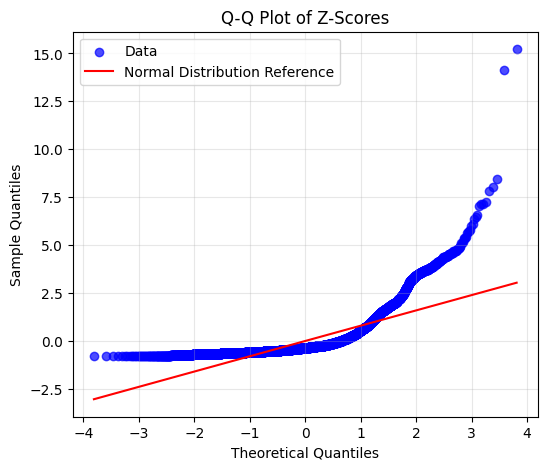

In [643]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
# Store the result of probplot
(osm, osr), (slope, intercept, r) = stats.probplot(trip_normalized, plot=ax)

# Clear previous plot and recreate with explicit handles for legend
ax.clear()
# Plot the data points
points = ax.scatter(osm, osr, color='blue', alpha=0.7, label='Data')
# Plot the reference line
line, = ax.plot(osm, slope*osm + intercept, 'r-', label='Normal Distribution Reference')

plt.title("Q-Q Plot of Z-Scores")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 13

In [644]:
s = pd.read_csv('data/nyc-temps.txt').squeeze()
hours = [0, 3, 6, 9, 12, 15, 18, 21]

In [645]:
s.info()

<class 'pandas.core.series.Series'>
RangeIndex: 728 entries, 0 to 727
Series name: -1
Non-Null Count  Dtype
--------------  -----
728 non-null    int64
dtypes: int64(1)
memory usage: 5.8 KB


Create a data frame with two columns: temp, with the temperatures, and hour, representing the hours at which the measurements were taken.
The hour values should be 0, 3, 6, 9, 12, 15, 18, and 21, repeated for all 728 data points.

In [646]:
df = pd.DataFrame({'temp': s, 'hour': hours * (len(s) // len(hours))})
df

,temp,hour
0,-1,0
1,-1,3
2,-1,6
3,-1,9
4,-1,12
...,...,...
723,2,9
724,2,12
725,2,15
726,2,18


In [647]:
df.describe()

,temp,hour
count,728.000000,728.000000
mean,-1.050824,10.500000
std,5.026357,6.878589
min,-14.000000,0.000000
25%,-4.000000,5.250000
50%,0.000000,10.500000
75%,2.000000,15.750000
max,12.000000,21.000000


Set all values from 3:00 and 6:00 a.m. to NaN

In [648]:
def set_temps_to_none(df, hours_to_nullify):
    """
    Sets temperature values to None for specified hours in the DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing 'hour' and 'temp' columns
    hours_to_nullify : list
        List of hour values for which to set temperature to None

    Returns:
    --------
    pandas.DataFrame
        DataFrame with temperature values set to None for specified hours
    """
    # Create a copy to avoid modifying the original
    result_df = df.copy()

    # Set temperature values to None for the specified hours
    result_df.loc[result_df['hour'].isin(hours_to_nullify), 'temp'] = None

    return result_df

Interpolate the values with the interpolate method.

In [649]:
df_nan = set_temps_to_none(df, [3, 6])
df_int = df_nan.interpolate()
df_int.describe()

,temp,hour
count,728.000000,728.000000
mean,-1.050824,10.500000
std,5.026357,6.878589
min,-14.000000,0.000000
25%,-4.000000,5.250000
50%,0.000000,10.500000
75%,2.000000,15.750000
max,12.000000,21.000000


How does the behavior of interpolate change if you use `method='nearest'`?

In [650]:
df_int_nearest = df_nan.interpolate(method='nearest')
df_int_nearest.describe()

,temp,hour
count,728.000000,728.000000
mean,-1.050824,10.500000
std,5.026357,6.878589
min,-14.000000,0.000000
25%,-4.000000,5.250000
50%,0.000000,10.500000
75%,2.000000,15.750000
max,12.000000,21.000000


 Let’s assume the equipment works fine around the clock but fails to record readings at –1 degrees and below. Are the interpolated values similar to the real (missing) values they replace?

The interpolated values are not similar to the real values they replace. The interpolation method estimates missing values based on surrounding data points, which can lead to inaccuracies, especially when the actual data has extreme values like -1 degrees.
Interpolation assumes a continuous trend, while the actual data may have abrupt changes or outliers.
This discrepancy can result in interpolated values that do not accurately reflect the true nature of the data, particularly in cases where the original data has significant variations or outliers.

In [651]:
df.loc[df['temp'] <= -1].describe()

,temp,hour
count,351.000000,351.000000
mean,-5.148148,10.470085
std,3.490516,6.870524
min,-14.000000,0.000000
25%,-6.000000,4.500000
50%,-4.000000,9.000000
75%,-3.000000,15.000000
max,-1.000000,21.000000


A cheap solution to interpolation is to replace NaN values with the column’s mean.

In [652]:
df.loc[df['temp'] <= -1,'temp'] = None
df.describe()

,temp,hour
count,377.000000,728.000000
mean,2.763926,10.500000
std,2.691589,6.878589
min,0.000000,0.000000
25%,1.000000,5.250000
50%,2.000000,10.500000
75%,5.000000,15.750000
max,12.000000,21.000000


In [653]:
df['temp'] = df['temp'].fillna(df['temp'].mean())
df.describe()

,temp,hour
count,728.000000,728.000000
mean,2.763926,10.500000
std,1.935689,6.878589
min,0.000000,0.000000
25%,2.000000,5.250000
50%,2.763926,10.500000
75%,2.763926,15.750000
max,12.000000,21.000000


# 14

Recreate the dataset with the temperature values from the previous exercise.

In [659]:
df = pd.DataFrame({'temp': s, 'hour': hours * (len(s) // len(hours))})

Set every value below 0 to 0.

In [660]:
df.loc[df['temp'] < 0, 'temp'] = 0

Set all the odd temperatures to the mean of all the temperatures

In [661]:
df.loc[df['temp'] % 2 != 0, 'temp'] = int(df['temp'].mean())
df.describe()

,temp,hour
count,728.000000,728.000000
mean,0.947802,10.500000
std,1.953383,6.878589
min,0.000000,0.000000
25%,0.000000,5.250000
50%,0.000000,10.500000
75%,1.000000,15.750000
max,12.000000,21.000000


Set the even temperatures at hours 9 and 18 to 3.

In [662]:
df.loc[(df['hour'].isin([9, 18])) & (df['temp'] % 2 == 0), 'temp'] = 3
df.describe()

,temp,hour
count,728.000000,728.000000
mean,1.329670,10.500000
std,1.868761,6.878589
min,0.000000,0.000000
25%,0.000000,5.250000
50%,1.000000,10.500000
75%,2.000000,15.750000
max,12.000000,21.000000


If the hour is odd, set the temperature to 5.

In [663]:
df.loc[df['hour'] % 2 != 0, 'temp'] = 5
df.describe()

,temp,hour
count,728.000000,728.000000
mean,3.163462,10.500000
std,2.263747,6.878589
min,0.000000,0.000000
25%,1.000000,5.250000
50%,5.000000,10.500000
75%,5.000000,15.750000
max,12.000000,21.000000
